In [32]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
from catboost import CatBoostClassifier, CatBoostRegressor
import lightgbm as lgb

In [2]:
df = pd.read_csv('adult.csv')

In [3]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
X = df.drop("income", axis=1)

In [6]:
y = df["income"].apply(lambda x: 1 if x.strip() == ">50K" else 0)

In [7]:
catcols = X.select_dtypes(include=['object']).columns.tolist()
numcols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [8]:
preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numcols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), catcols)]
)

In [12]:
pipelineada = Pipeline([
    ('preprocess', preprocessor),
    ('adaboost', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    ))
])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
pipelineada.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'fnlwgt',
                                                   'educational-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native-country'])])),
                ('adaboost',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                    random_state=42))])

In [26]:
def explain_adaboost(model, X_train, X_test, y_train, y_test, features=None):
    y_pred = model.predict(X_test)
    y_pred_tr = model.predict(X_train)
    print('Test Results:')
    print(classification_report(y_test, y_pred))
    print('Confusion Matrix:', confusion_matrix(y_test, y_pred))
    print('Train Results:')
    print(classification_report(y_train, y_pred_tr))
    print('Confusion Matrix:', confusion_matrix(y_train, y_pred_tr))

In [27]:
explain_adaboost(pipelineada, X_train, X_test, y_train, y_test)

Test Results:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7479
           1       0.78      0.54      0.64      2290

    accuracy                           0.86      9769
   macro avg       0.83      0.75      0.78      9769
weighted avg       0.85      0.86      0.85      9769

Confusion Matrix: [[7134  345]
 [1047 1243]]
Train Results:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     29676
           1       0.79      0.53      0.64      9397

    accuracy                           0.85     39073
   macro avg       0.83      0.74      0.77     39073
weighted avg       0.85      0.85      0.84     39073

Confusion Matrix: [[28307  1369]
 [ 4381  5016]]


In [28]:
def explain_boosting_model(pipeline, X_train, X_test, y_train, y_test, numerical_cols=None, categorical_cols=None, top_n_features=20):
    
    start_train = time.time()
    pipeline.fit(X_train, y_train)
    end_train = time.time()
    train_time = end_train - start_train

    start_pred = time.time()
    y_pred = pipeline.predict(X_test)
    y_pred_train = pipeline.predict(X_train)
    end_pred = time.time()
    pred_time = end_pred - start_pred

    metrics_test = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1])
    }

    metrics_train = {
        "Accuracy": accuracy_score(y_train, y_pred_train),
        "Precision": precision_score(y_train, y_pred_train),
        "Recall": recall_score(y_train, y_pred_train),
        "F1-Score": f1_score(y_train, y_pred_train),
        "ROC-AUC": roc_auc_score(y_train, pipeline.predict_proba(X_train)[:,1])
    }

    print("Train results")
    for k,v in metrics_train.items():
        print(f"{k}: {v:.4f}")
    print("test results")
    for k,v in metrics_test.items():
        print(f"{k}: {v:.4f}")
    print(f"Training Time: {train_time:.2f} s, Prediction Time: {pred_time:.2f} s")

    plt.figure(figsize=(8,5))
    plt.bar(metrics_test.keys(), metrics_test.values(), color='skyblue')
    plt.title("Test Performance Metrics")
    plt.ylabel("Score")
    plt.ylim(0,1)
    plt.show()

    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy', n_jobs=-1
    )
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='blue', label='Train score')
    plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', color='red', label='CV score')
    plt.title('Learning Curve')
    plt.xlabel('Training examples')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    if categorical_cols:
        cat_features = pipeline.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
    else:
        cat_features = []

    if numerical_cols:
        num_features = numerical_cols
    else:
        num_features = []

    all_features = np.concatenate([num_features, cat_features])
    importances = pipeline.named_steps[list(pipeline.named_steps.keys())[-1]].feature_importances_

    import pandas as pd
    feat_imp = pd.Series(importances, index=all_features)
    top_features = feat_imp.sort_values(ascending=False).head(top_n_features)

    plt.figure(figsize=(10,6))
    top_features.plot(kind='barh', color='skyblue')
    plt.title(f"Top {top_n_features} Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


Train results
Accuracy: 0.8528
Precision: 0.7856
Recall: 0.5338
F1-Score: 0.6357
ROC-AUC: 0.9061
test results
Accuracy: 0.8575
Precision: 0.7827
Recall: 0.5428
F1-Score: 0.6411
ROC-AUC: 0.9076
Training Time: 5.64 s, Prediction Time: 1.34 s


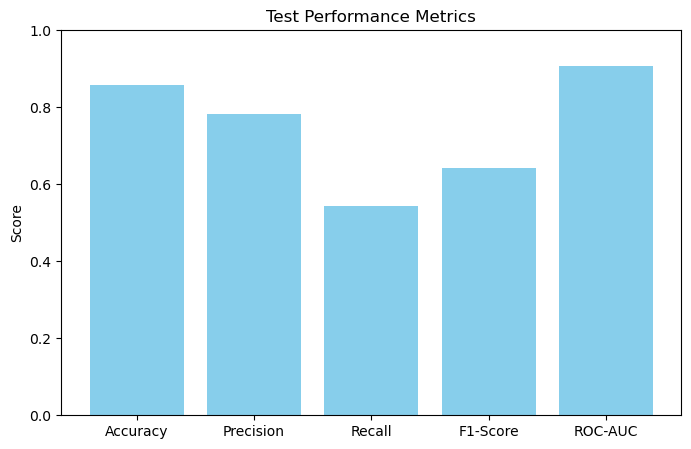

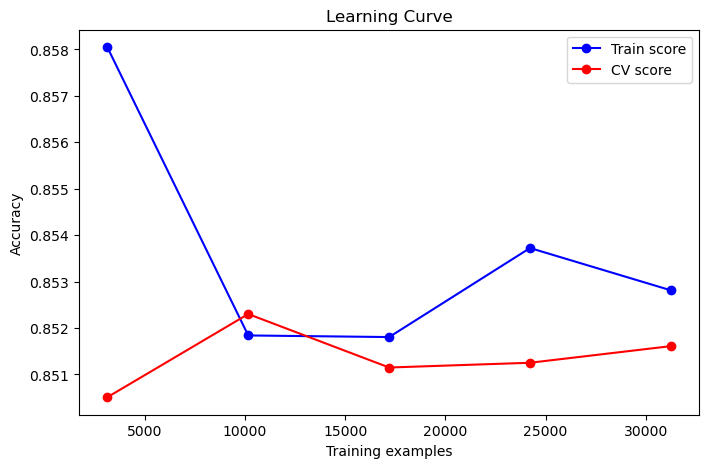

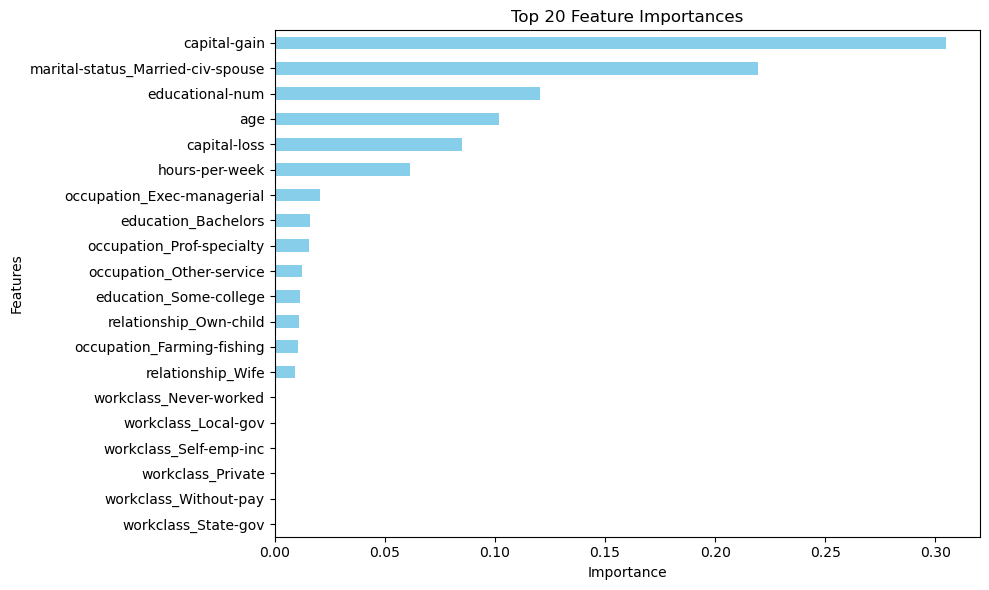

In [29]:
explain_boosting_model(
    pipeline=pipelineada,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    numerical_cols=numcols,
    categorical_cols=catcols
)


In [34]:
pipelinexgb = Pipeline([
    ('preprocess', preprocessor),
    ('xgb', xgb.XGBClassifier(
        n_estimators=50,
        learning_rate=1.0,
        max_depth=1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

C:\Users\ufml\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:30:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train results
Accuracy: 0.8631
Precision: 0.7751
Recall: 0.6066
F1-Score: 0.6806
ROC-AUC: 0.9172
test results
Accuracy: 0.8695
Precision: 0.7769
Recall: 0.6218
F1-Score: 0.6908
ROC-AUC: 0.9197
Training Time: 0.56 s, Prediction Time: 0.36 s


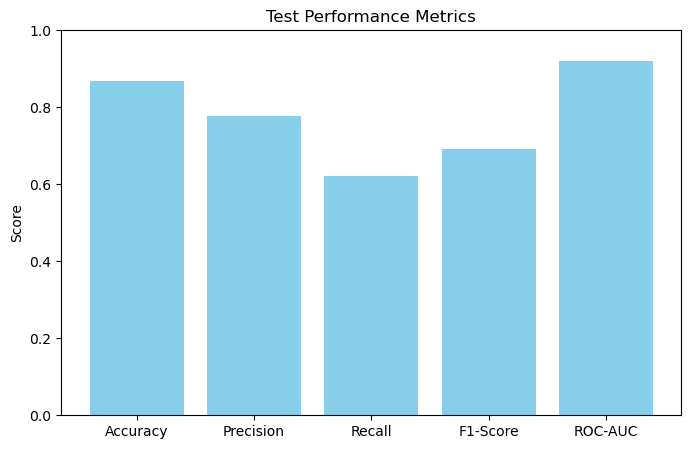

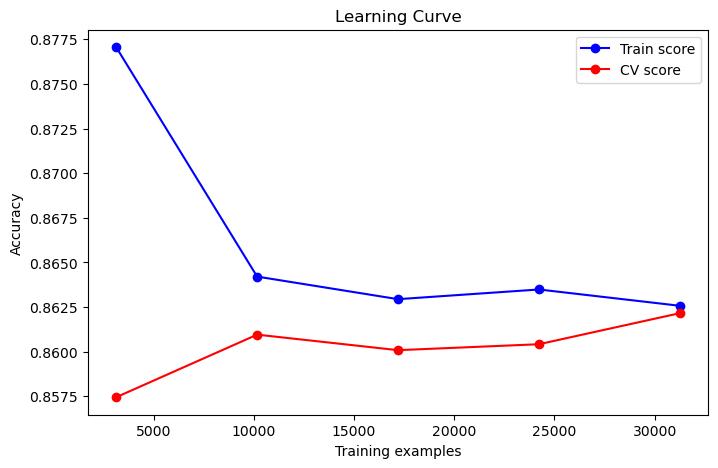

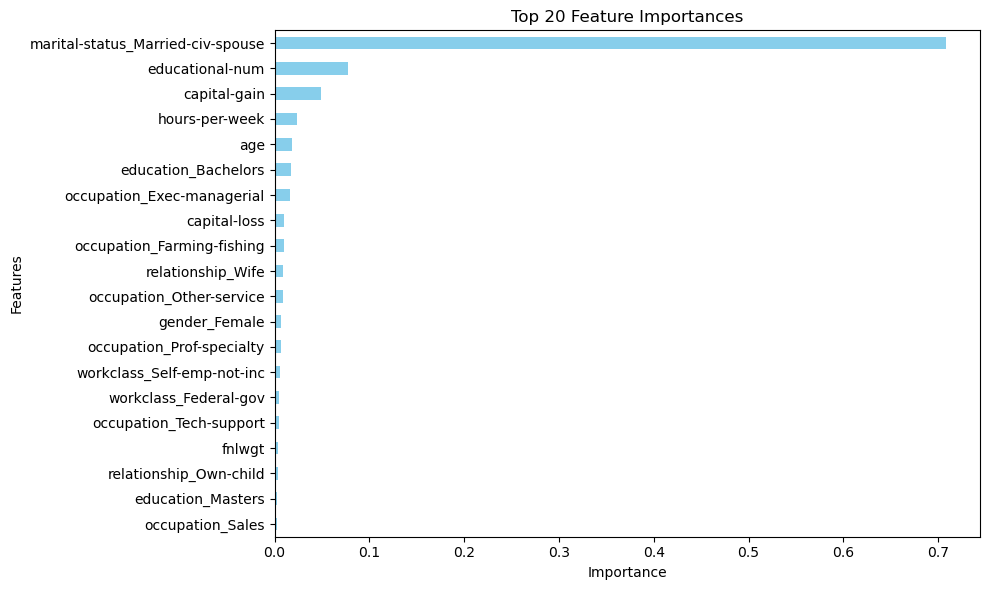

In [35]:
explain_boosting_model(
    pipeline=pipelinexgb,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    numerical_cols=numcols,
    categorical_cols=catcols
)


In [36]:
pipelinelgb = Pipeline([
    ('preprocess', preprocessor),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=50,
        learning_rate=1.0,
        max_depth=1,
        random_state=42
    ))
])

[LightGBM] [Info] Number of positive: 9397, number of negative: 29676
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 98
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240499 -> initscore=-1.149948
[LightGBM] [Info] Start training from score -1.149948
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

C:\Users\ufml\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ufml\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ufml\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ufml\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train results
Accuracy: 0.8629
Precision: 0.7753
Recall: 0.6057
F1-Score: 0.6801
ROC-AUC: 0.9168
test results
Accuracy: 0.8695
Precision: 0.7778
Recall: 0.6205
F1-Score: 0.6903
ROC-AUC: 0.9191
Training Time: 0.50 s, Prediction Time: 0.36 s


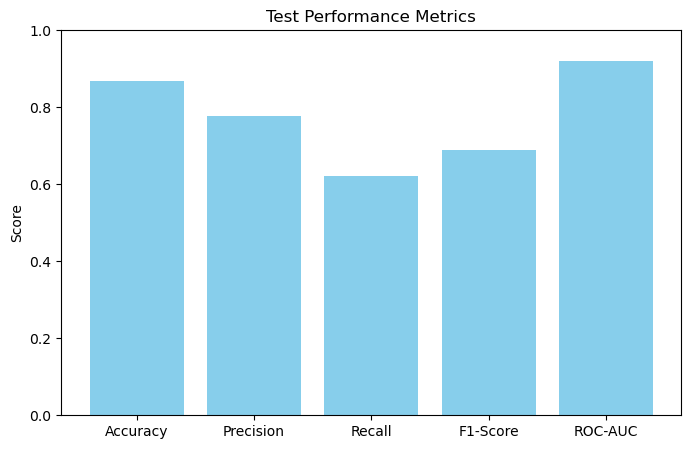

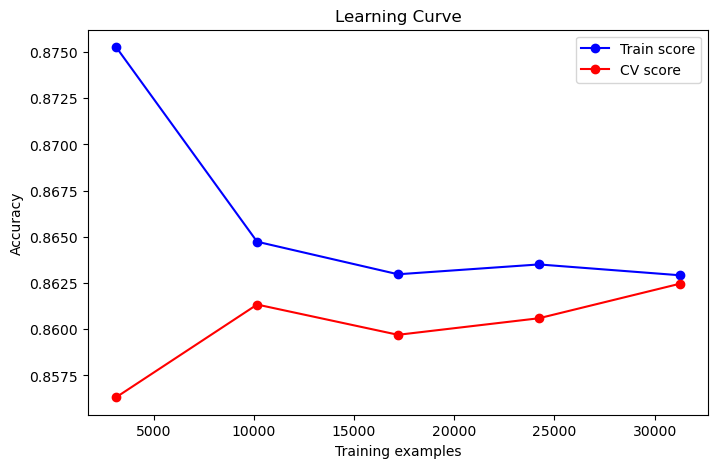

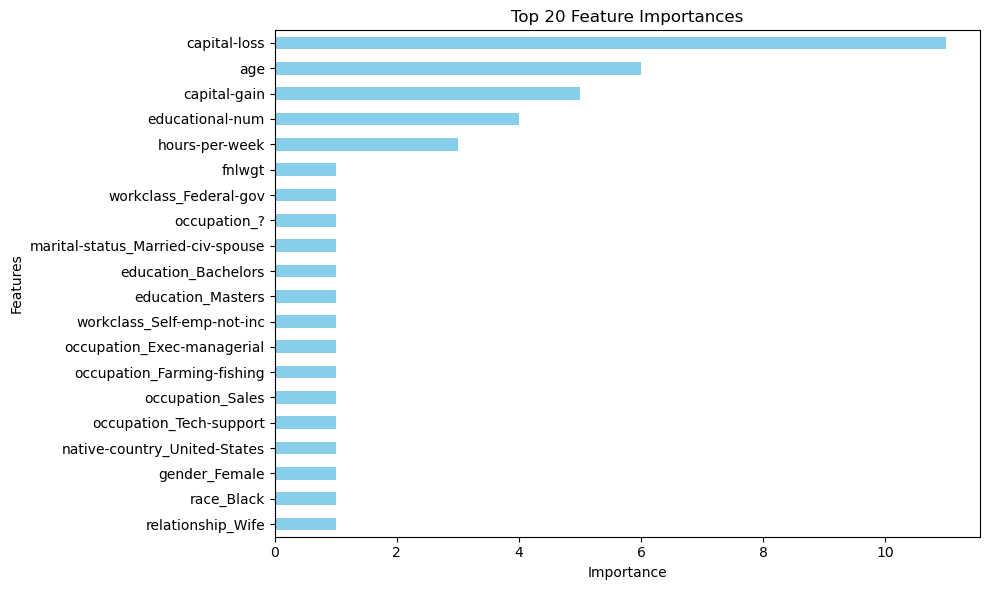

In [38]:
explain_boosting_model(
    pipeline=pipelinelgb,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    numerical_cols=numcols,
    categorical_cols=catcols,
    top_n_features=20
)


In [40]:
pipelinecb = Pipeline([
    ('preprocess', preprocessor),
    ('catboost', CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=0
    ))
])

Train results
Accuracy: 0.8735
Precision: 0.8013
Recall: 0.6301
F1-Score: 0.7055
ROC-AUC: 0.9298
test results
Accuracy: 0.8780
Precision: 0.7971
Recall: 0.6432
F1-Score: 0.7119
ROC-AUC: 0.9289
Training Time: 4.05 s, Prediction Time: 0.51 s


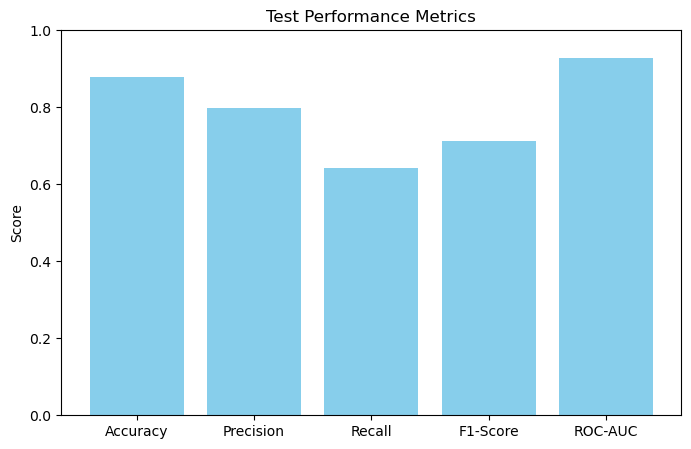

C:\Users\ufml\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


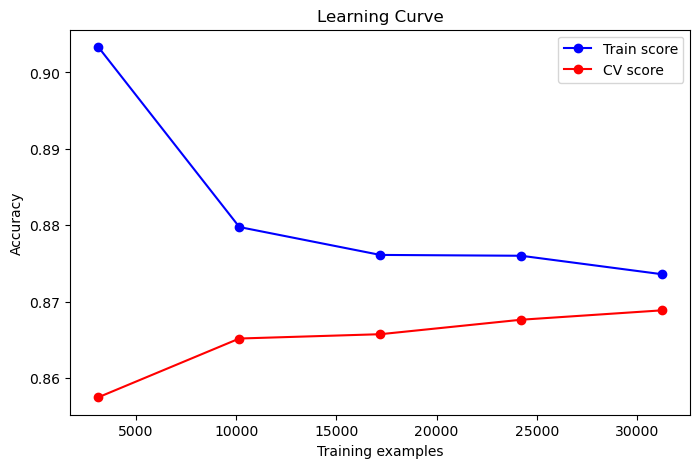

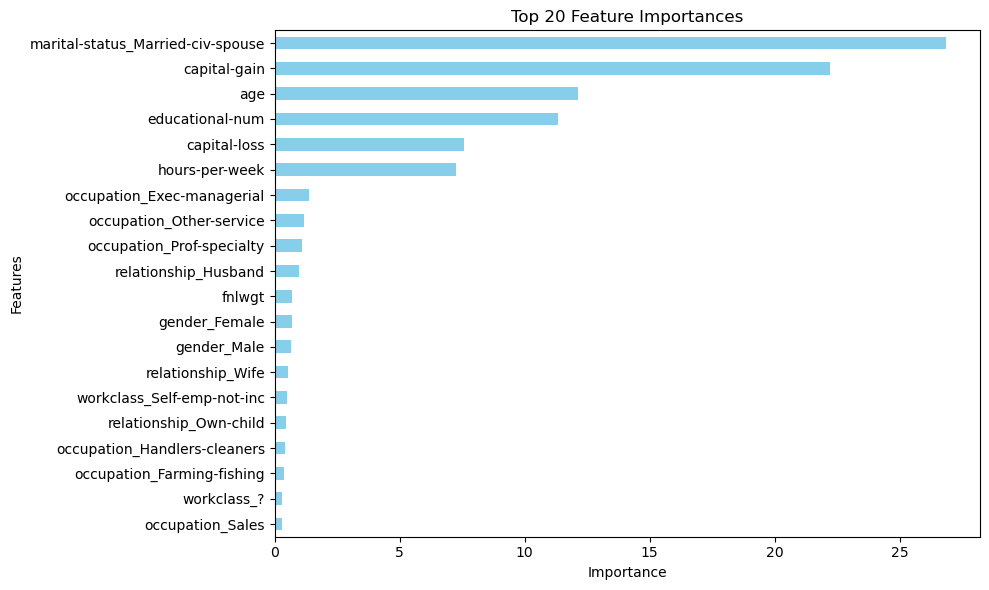

In [41]:
explain_boosting_model(
    pipeline=pipelinecb,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    numerical_cols=numcols,
    categorical_cols=catcols,
    top_n_features=20
)

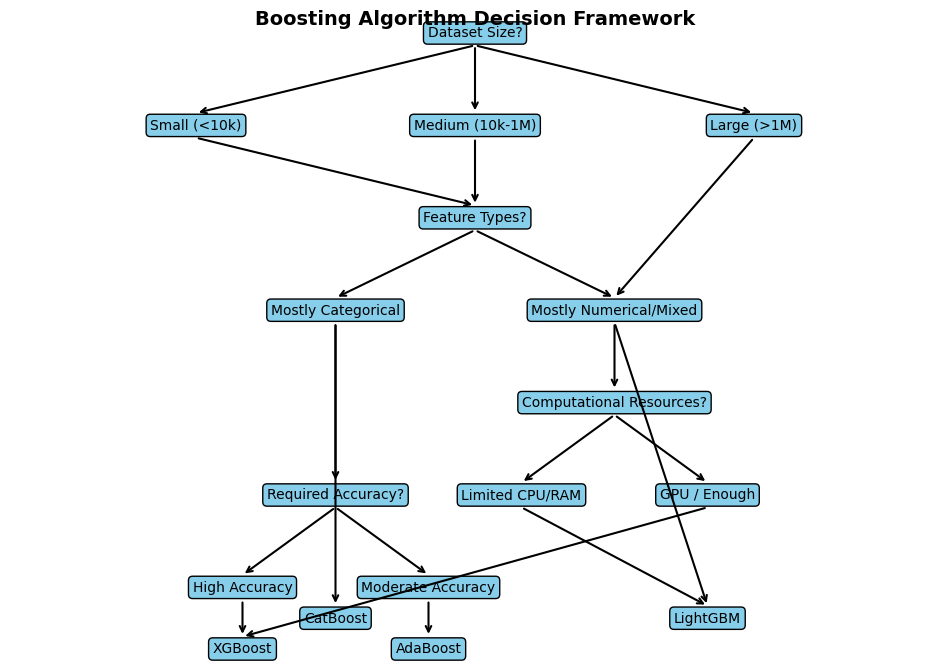

In [44]:
boxes = {
    "Dataset Size?": (0.5, 1.0),
    "Small (<10k)": (0.2, 0.85),
    "Medium (10k-1M)": (0.5, 0.85),
    "Large (>1M)": (0.8, 0.85),
    "Feature Types?": (0.5, 0.7),
    "Mostly Categorical": (0.35, 0.55),
    "Mostly Numerical/Mixed": (0.65, 0.55),
    "Computational Resources?": (0.65, 0.4),
    "Limited CPU/RAM": (0.55, 0.25),
    "GPU / Enough": (0.75, 0.25),
    "Required Accuracy?": (0.35, 0.25),
    "High Accuracy": (0.25, 0.1),
    "Moderate Accuracy": (0.45, 0.1),
    "CatBoost": (0.35, 0.05),
    "LightGBM": (0.75, 0.05),
    "XGBoost": (0.25, 0.0),
    "AdaBoost": (0.45, 0.0)
}

connections = [
    ("Dataset Size?", "Small (<10k)"),
    ("Dataset Size?", "Medium (10k-1M)"),
    ("Dataset Size?", "Large (>1M)"),
    ("Small (<10k)", "Feature Types?"),
    ("Medium (10k-1M)", "Feature Types?"),
    ("Large (>1M)", "Mostly Numerical/Mixed"),
    ("Feature Types?", "Mostly Categorical"),
    ("Feature Types?", "Mostly Numerical/Mixed"),
    ("Mostly Categorical", "Required Accuracy?"),
    ("Mostly Numerical/Mixed", "Computational Resources?"),
    ("Computational Resources?", "Limited CPU/RAM"),
    ("Computational Resources?", "GPU / Enough"),
    ("Required Accuracy?", "High Accuracy"),
    ("Required Accuracy?", "Moderate Accuracy"),
    ("High Accuracy", "XGBoost"),
    ("Moderate Accuracy", "AdaBoost"),
    ("Mostly Categorical", "CatBoost"),
    ("Limited CPU/RAM", "LightGBM"),
    ("GPU / Enough", "XGBoost"),
    ("Mostly Numerical/Mixed", "LightGBM")
]

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

for label, (x, y) in boxes.items():
    ax.text(x, y, label, ha='center', va='center',
            bbox=dict(facecolor='skyblue', boxstyle='round,pad=0.3'), fontsize=10)

for start, end in connections:
    start_x, start_y = boxes[start]
    end_x, end_y = boxes[end]
    ax.annotate("",
                xy=(end_x, end_y+0.02),
                xytext=(start_x, start_y-0.02),
                arrowprops=dict(arrowstyle="->", lw=1.5))

plt.title("Boosting Algorithm Decision Framework", fontsize=14, fontweight='bold')
plt.show()